In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_path = '/content/drive/MyDrive/DATASET/mitbih_train.csv'
test_path = '/content/drive/MyDrive/DATASET/mitbih_test.csv'

try:
    df_train = pd.read_csv(train_path, header=None)
    df_test = pd.read_csv(test_path, header=None)

    print("Training data head:")
    display(df_train.head())

    print("\nTesting data head:")
    display(df_test.head())

    print("\nTraining data info:")
    df_train.info()

    print("\nTesting data info:")
    df_test.info()

except FileNotFoundError:
    print("Error: Make sure the file paths are correct and the files exist in your Google Drive.")
    print(f"Attempted paths: {train_path}, {test_path}")


Training data head:


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Testing data head:


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Training data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87554 entries, 0 to 87553
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 125.6 MB

Testing data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21892 entries, 0 to 21891
Columns: 188 entries, 0 to 187
dtypes: float64(188)
memory usage: 31.4 MB


In [ ]:
# Separate features and target
X_train = df_train.iloc[:, :-1].values
y_train = df_train.iloc[:, -1].values
X_test = df_test.iloc[:, :-1].values
y_test = df_test.iloc[:, -1].values

# Reshape data for CNN 1D (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

num_classes = len(np.unique(y_train))
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (87554, 187, 1)
y_train shape: (87554, 5)
X_test shape: (21892, 187, 1)
y_test shape: (21892, 5)


In [ ]:
# Split training data into training and validation sets
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

print("X_train_split shape:", X_train_split.shape)
print("X_val shape:", X_val.shape)
print("y_train_split shape:", y_train_split.shape)
print("y_val shape:", y_val.shape)

X_train_split shape: (78798, 187, 1)
X_val shape: (8756, 187, 1)
y_train_split shape: (78798, 5)
y_val shape: (8756, 5)


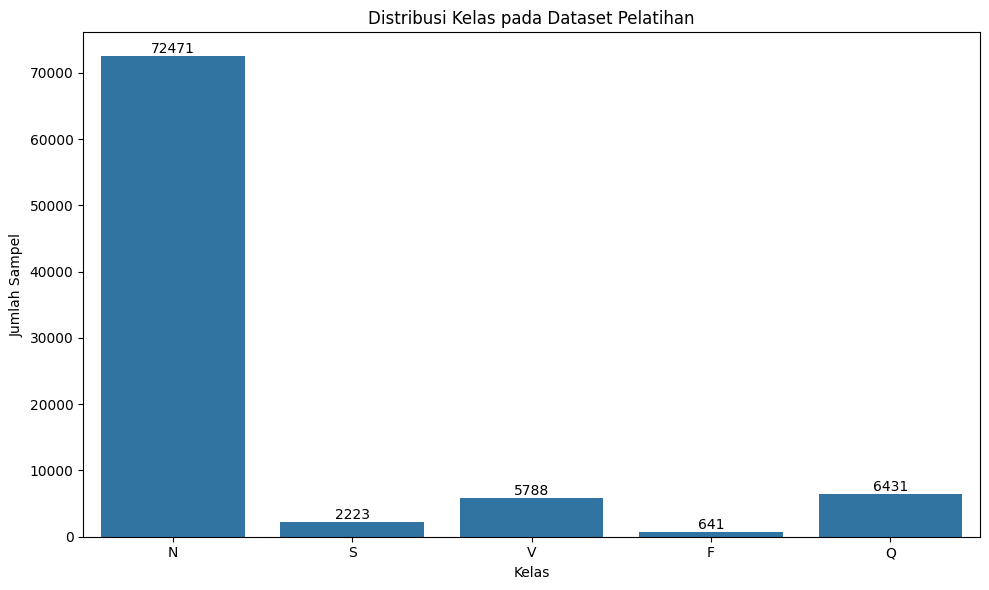

In [ ]:
class_counts = df_train.iloc[:, -1].value_counts()

class_labels = {0: 'N', 1: 'S', 2: 'V', 3: 'F', 4: 'Q'}

sorted_labels = sorted(class_labels.keys())
sorted_counts = [class_counts[label] for label in sorted_labels]
sorted_class_names = [class_labels[label] for label in sorted_labels]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=sorted_class_names, y=sorted_counts)

for i, value in enumerate(sorted_counts):
    ax.text(
        i,
        value,
        f'{value}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Distribusi Kelas pada Dataset Pelatihan')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
from imblearn.combine import SMOTEENN

X_train_flat = X_train_split.reshape(X_train_split.shape[0], -1)


smoteenn = SMOTEENN(
    random_state=42,
    smote=None,
    enn=None
)

X_train_resampled, y_train_resampled = smoteenn.fit_resample(
    X_train_flat,
    y_train_split
)


X_train_resampled = X_train_resampled.reshape(
    X_train_resampled.shape[0],
    X_train_split.shape[1],
    1
)


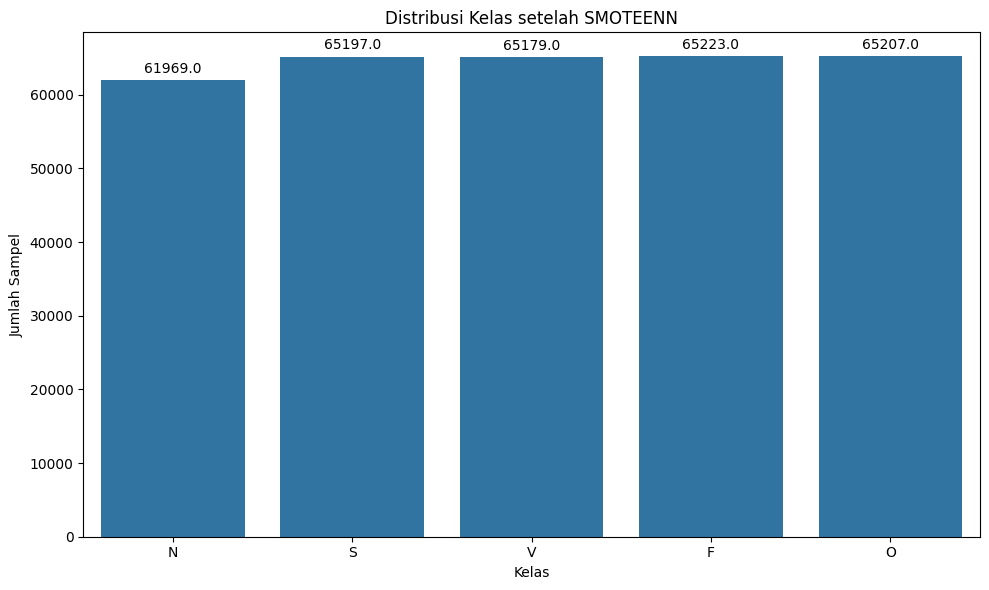

In [ ]:
# Plot the class distribution after SMOTEENN
plt.figure(figsize=(10, 6))
# Convert one-hot encoded y_train_resampled to class indices
resampled_class_indices = np.argmax(y_train_resampled, axis=1)
ax = sns.countplot(x=resampled_class_indices)

# Map numerical classes to descriptive labels
class_labels = {0: 'N', 1: 'S', 2: 'V', 3: 'F', 4: 'O'}
ax.set_xticks(np.arange(len(class_labels)))
ax.set_xticklabels(list(class_labels.values()))

# Tambahin angka di atas bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.title('Distribusi Kelas setelah SMOTEENN')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

def build_cnn1d_model(input_shape, num_classes, kernel_size, dropout_last):
    """Improved CNN1D with progressive filters, BN, and hidden dense layer"""
    model = Sequential()

    # Block 1
    model.add(Conv1D(filters=64, kernel_size=kernel_size, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=3))
    model.add(Dropout(0.5))

    # Block 2
    model.add(Conv1D(filters=128, kernel_size=kernel_size, activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=3))
    model.add(Dropout(0.5))

    # Block 3
    model.add(Conv1D(filters=128, kernel_size=kernel_size, activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=3))
    model.add(Dropout(0.5))

    # Flatten
    model.add(Flatten())

    # Dense hidden layer
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(dropout_last))

    # Output
    model.add(Dense(num_classes, activation='softmax'))

    return model


# Input shape
input_shape = (X_train_split.shape[1], X_train_split.shape[2])

# Model 1: kernel size 5
model1 = build_cnn1d_model(input_shape, num_classes, kernel_size=5, dropout_last=0.5)

# Model 2: kernel size 7
model2 = build_cnn1d_model(input_shape, num_classes, kernel_size=7, dropout_last=0.5)

# Model 3: kernel size 10
model3 = build_cnn1d_model(input_shape, num_classes, kernel_size=10, dropout_last=0.5)

# Print summary masing-masing
print("Model 1 (Kernel Size 5):")
model1.summary()

print("\nModel 2 (Kernel Size 7):")
model2.summary()

print("\nModel 3 (Kernel Size 10):")
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 1 (Kernel Size 5):


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 183, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 183, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 61, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 61, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 57, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 57, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 15, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 15, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,493 (810.52 KB)

...

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 178, 64)        │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 178, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 59, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 59, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 50, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 7, 128)         │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,541 (1.07 MB)

 Trainable params: 280,901 (1.07 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
# Compile model1
model1.compile(optimizer=Adam(),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

# Compile model2
model2.compile(optimizer=Adam(),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

# Compile model3
model3.compile(optimizer=Adam(),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

print("Model 1 compiled successfully.")
print("Model 2 compiled successfully.")
print("Model 3 compiled successfully.")

Model 1 compiled successfully.
Model 2 compiled successfully.
Model 3 compiled successfully.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


# Train model1
print("Training model 1...")
history1 = model1.fit(
    X_train_resampled, y_train_resampled,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

# Train model2
print("\nTraining model 2...")
history2 = model2.fit(
    X_train_resampled, y_train_resampled,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

# Train model3
print("\nTraining model 3...")
history3 = model3.fit(
    X_train_resampled, y_train_resampled,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

print("\nAll models trained successfully.")

Training model 1...
Epoch 1/100
10087/10087 ━━━━━━━━━━━━━━━━━━━━ 51s 4ms/step - accuracy: 0.7866 - loss: 0.6087 - val_accuracy: 0.8941 - val_loss: 0.3161
Epoch 2/100
10087/10087 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - accuracy: 0.9137 - loss: 0.2426 - val_accuracy: 0.9183 - val_loss: 0.2777
Epoch 3/100
10087/10087 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - accuracy: 0.9326 - loss: 0.1934 - val_accuracy: 0.9108 - val_loss: 0.2652
Epoch 4/100
10087/10087 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - accuracy: 0.9399 - loss: 0.1714 - val_accuracy: 0.9237 - val_loss: 0.2237
Epoch 5/100
10087/10087 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - accuracy: 0.9457 - loss: 0.1552 - val_accuracy: 0.9334 - val_loss: 0.2068
Epoch 6/100
10087/10087 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - accuracy: 0.9490 - loss: 0.1455 - val_accuracy: 0.8896 - val_loss: 0.3273
Epoch 7/100
10087/10087 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step - accuracy: 0.9526 - loss: 0.1370 - val_accuracy: 0.9344 - val_loss: 0.2018
Epoch 8/100
10087/10087 ━━━━━━━━━━━━━━━━━━

In [ ]:
# Evaluate each model individually on the test data
print("Classification Report for Model 1 (Kernel Size 5):")
y_pred1 = model1.predict(X_test)
y_pred_classes1 = np.argmax(y_pred1, axis=1)
true_classes_test = np.argmax(y_test, axis=1) # Ensure true_classes_test is defined
print(classification_report(true_classes_test, y_pred_classes1, digits=4))

print("\nClassification Report for Model 2 (Kernel Size 7):")
y_pred2 = model2.predict(X_test)
y_pred_classes2 = np.argmax(y_pred2, axis=1)
print(classification_report(true_classes_test, y_pred_classes2, digits=4))

print("\nClassification Report for Model 3 (Kernel Size 10):")
y_pred3 = model3.predict(X_test)
y_pred_classes3 = np.argmax(y_pred3, axis=1)
print(classification_report(true_classes_test, y_pred_classes3, digits=4))

Classification Report for Model 1 (Kernel Size 5):
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision    recall  f1-score   support

           0     0.9949    0.9661    0.9803     18118
           1     0.5408    0.8705    0.6671       556
           2     0.9299    0.9530    0.9413      1448
           3     0.4966    0.8889    0.6372       162
           4     0.9779    0.9913    0.9846      1608

    accuracy                         0.9641     21892
   macro avg     0.7880    0.9340    0.8421     21892
weighted avg     0.9741    0.9641    0.9675     21892


Classification Report for Model 2 (Kernel Size 7):
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
              precision    recall  f1-score   support

           0     0.9936    0.9696    0.9815     18118
           1     0.5460    0.8759    0.6727       556
           2     0.9603    0.9358    0.9479      1448
           3     0.5070    0.8889    0.6457       162
           4     0.9785    0.9888    0.9836      1608



685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Ensemble Model Accuracy: 0.9679

Classification Report:
              precision    recall  f1-score   support

           0     0.9941    0.9713    0.9826     18118
           1     0.5724    0.8741    0.6918       556
           2     0.9514    0.9454    0.9484      1448
           3     0.5333    0.8889    0.6667       162
           4     0.9767    0.9907    0.9836      1608

    accuracy                         0.9679     21892
   macro avg     0.8056    0.9341    0.8546     21892
weighted avg     0.9759    0.9679    0.9707     21892



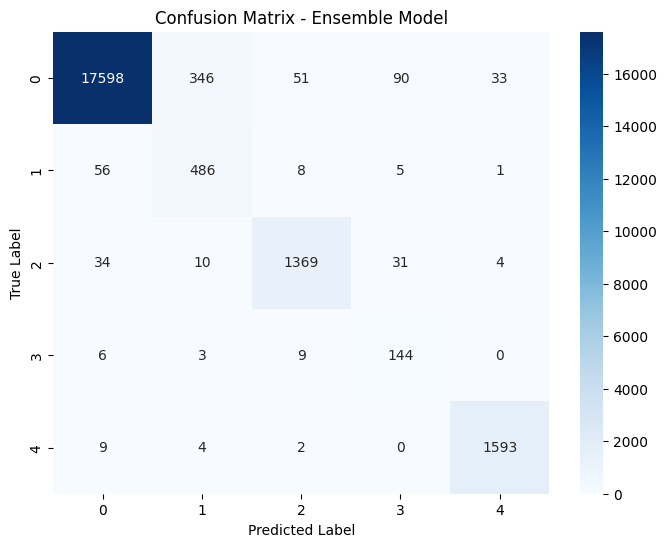

In [ ]:
predictions1 = model1.predict(X_test)
predictions2 = model2.predict(X_test)
predictions3 = model3.predict(X_test)

# Get the predicted class index for each model
predicted_classes1 = np.argmax(predictions1, axis=1)
predicted_classes2 = np.argmax(predictions2, axis=1)
predicted_classes3 = np.argmax(predictions3, axis=1)

# Combine predictions using majority voting
ensemble_predictions = np.array([predicted_classes1, predicted_classes2, predicted_classes3])
final_predictions = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=ensemble_predictions)

true_classes = np.argmax(y_test, axis=1)

# Calculate accuracy
accuracy = accuracy_score(true_classes, final_predictions)
print(f"Ensemble Model Accuracy: {accuracy:.4f}")

# Generate classification report
report = classification_report(true_classes, final_predictions, digits=4)
print("\nClassification Report:")
print(report)

# Generate confusion matrix
cm = confusion_matrix(true_classes, final_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Ensemble Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

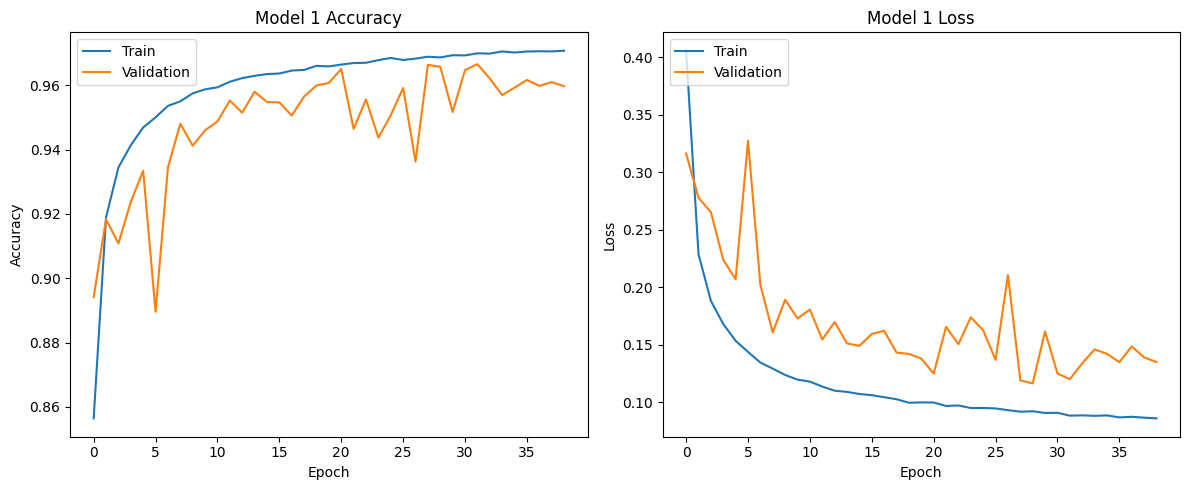

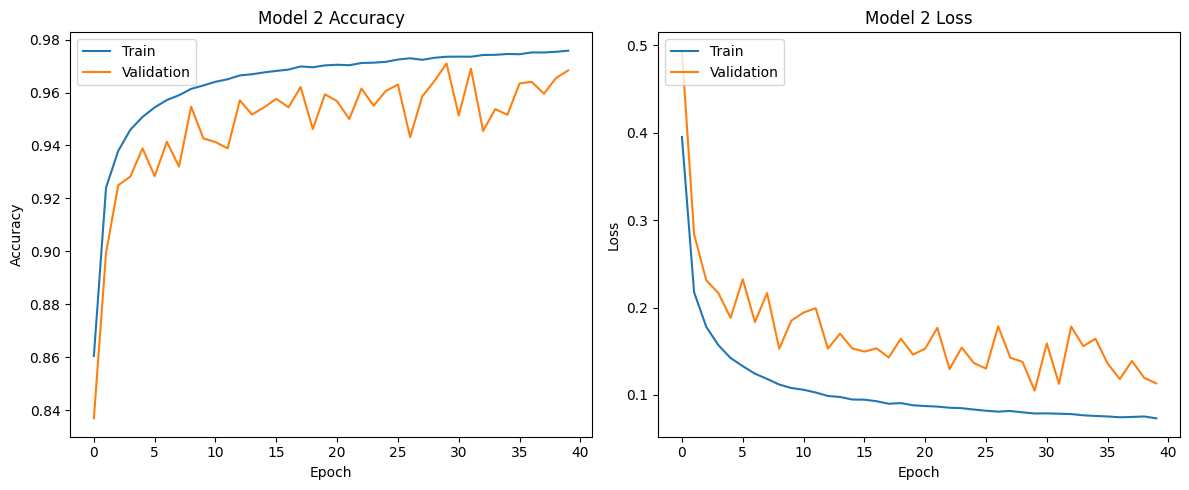

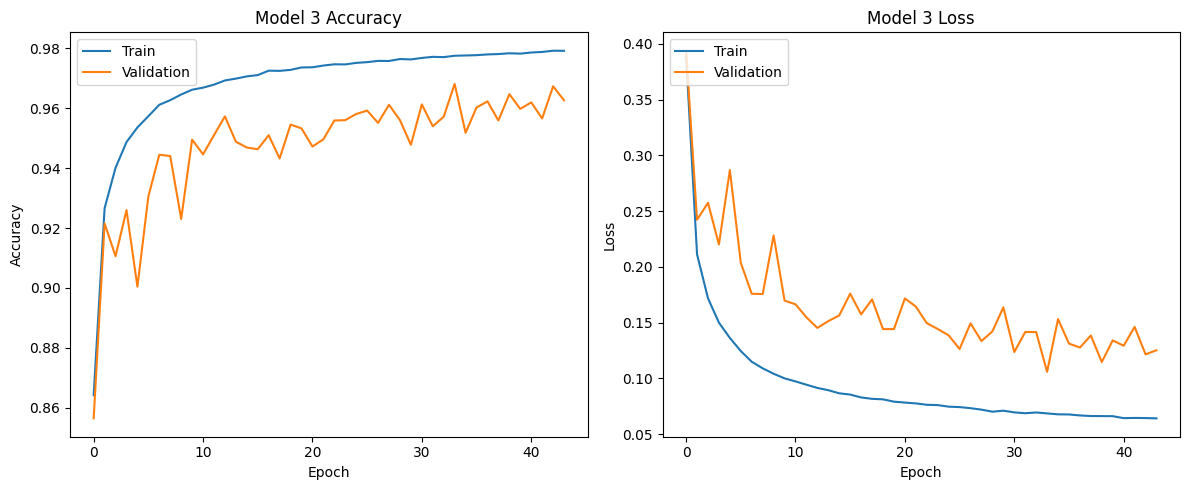

In [ ]:

# Plot learning curves for each model
def plot_learning_curve(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.show()

plot_learning_curve(history1, 'Model 1')
plot_learning_curve(history2, 'Model 2')
plot_learning_curve(history3, 'Model 3')

685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


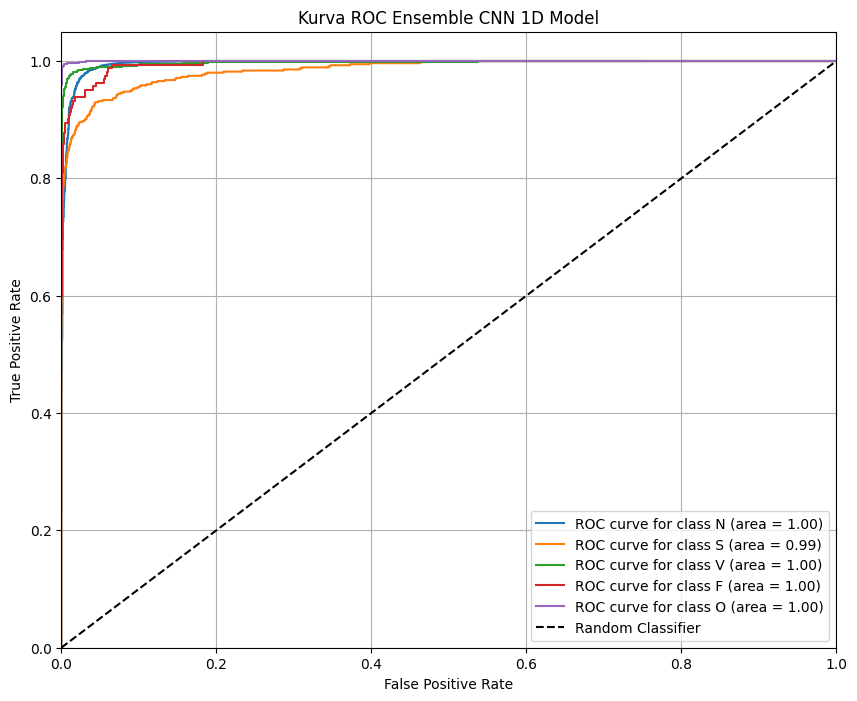

In [ ]:


probabilities1 = model1.predict(X_test)
probabilities2 = model2.predict(X_test)
probabilities3 = model3.predict(X_test)

# Average the probabilities
ensemble_probabilities = (probabilities1 + probabilities2 + probabilities3) / 3

plt.figure(figsize=(10, 8))

# Map numerical classes to descriptive labels
class_labels = {0: 'N', 1: 'S', 2: 'V', 3: 'F', 4: 'O'}

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test[:, i], ensemble_probabilities[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve for class {class_labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Kurva ROC Ensemble CNN 1D Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()